In [1]:
import torch
from torch import nn

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.8.0+cpu'

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory , creating one...")
    image_path.mkdir(parents=True, exist_ok=True)


    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading...")
        f.write(requests.content)

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping...")
        zip_ref.extractall(image_path)


data/pizza_steak_sushi directory exists.


In [17]:
import os 
def walk_through_dir(dir_path): 
    for dirpath, dirnames, filenames in os.walk(dir_path): 
        print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")

In [18]:
walk_through_dir(image_path)

There are 2 directories and 0 files in 'data/pizza_steak_sushi'.
There are 3 directories and 0 files in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 files in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 files in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 files in 'data/pizza_steak_sushi/test/sushi'.
There are 3 directories and 0 files in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 files in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 files in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 files in 'data/pizza_steak_sushi/train/sushi'.


In [19]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path : data/pizza_steak_sushi/test/sushi/1987407.jpg
Image class : sushi
Image Width : 512
Image Height : 384


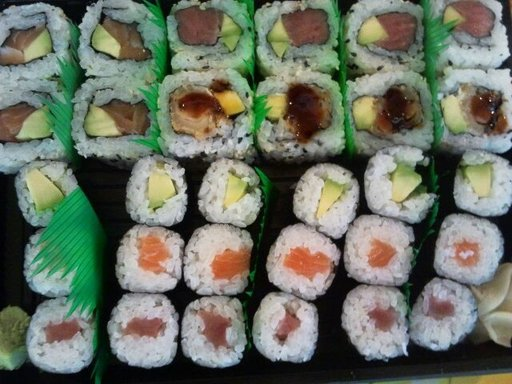

In [20]:
import random
from PIL import Image

random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))
random_image_path=random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Random image path : {random_image_path}")
print(f"Image class : {image_class}")

print(f"Image Width : {img.width}")
print(f"Image Height : {img.height}")
img

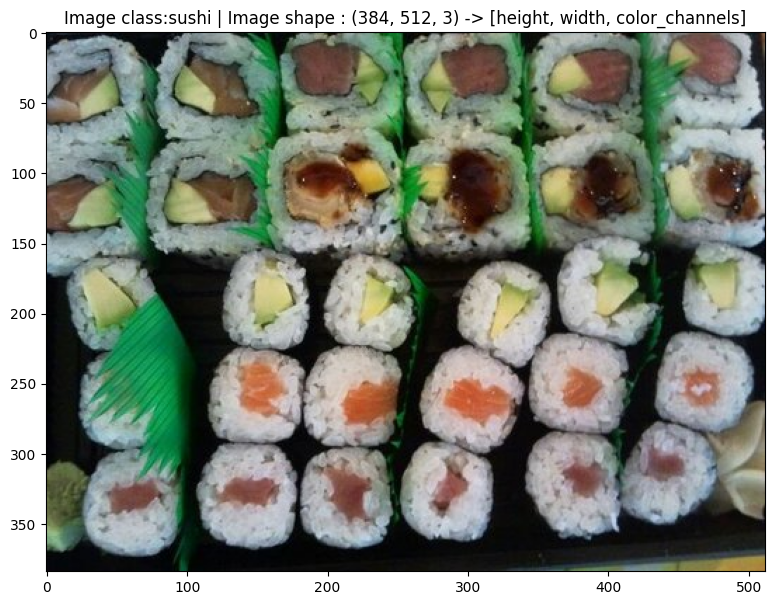

In [21]:
import numpy as np
import matplotlib.pyplot as plt 
img_as_array = np.array(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class:{image_class} | Image shape : {img_as_array.shape} -> [height, width, color_channels]")
plt.show()

In [22]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets , transforms

In [50]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

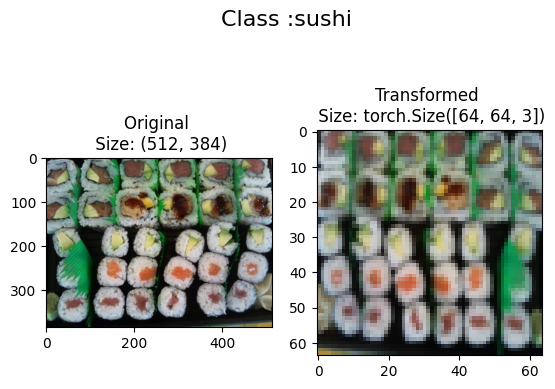

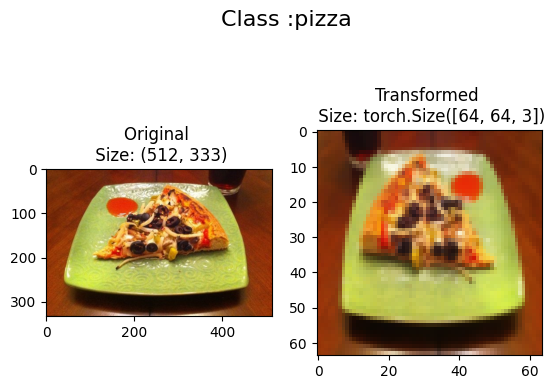

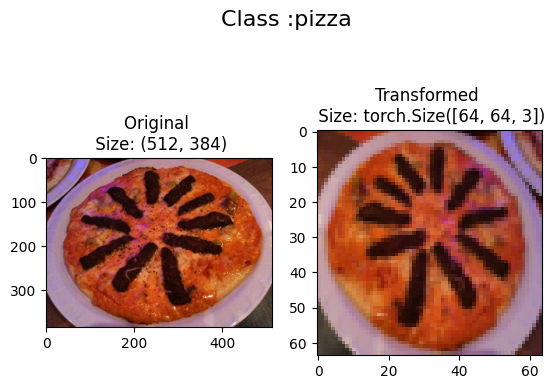

In [52]:
def plot_transformed_images(image_paths, transform , n=3):
    random.seed(42)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
            with Image.open(image_path) as f:
                  fig,ax = plt.subplots(1,2)
                  ax[0].imshow(f)
                  ax[0].set_title(f"Original \n Size: {f.size}")
                  ax[0].axis("on")


                  transformed_image = transform(f).permute(1,2,0)
                  ax[1].imshow(transformed_image)
                  ax[1].set_title(f"Transformed \n Size: {transformed_image.shape}")
                  ax[1].axis("on")

                  fig.suptitle(f"Class :{image_path.parent.stem}",fontsize=16)
plot_transformed_images(image_path_list,data_transform)


In [62]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)

test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

print(f"Train data : \n{train_data} \n Test data :\n{test_data}")

Train data : 
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ) 
 Test data :
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [44]:
class_names  = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [54]:
len(train_data),len(test_data)

(225, 75)

In [57]:
img , label = train_data[0][0] , train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

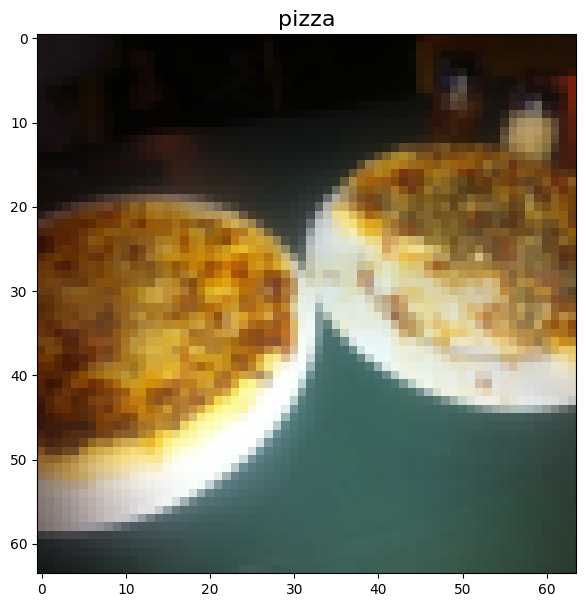

In [ ]:
img_permute = img.permute(1,2,0)

print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]") 


plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1,2,0))
plt.axis("on")
plt.title(class_names[label],fontsize=16)